# LeetCode #1404: Number of Steps to Reduce a Number in Binary Representation to One

https://leetcode.com/problems/number-of-steps-to-reduce-a-number-in-binary-representation-to-one/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n^2)$ | $O(n)$ |
| **Linear Scan with Carry** ★ | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
Directly simulate each operation on the string: if the last character is '0' remove it (right shift), otherwise convert the string by adding 1 (propagating carry). Each add can cascade through $O(n)$ characters, making the total $O(n^2)$.

### Optimal: Linear Scan with Carry ★
Process bits from right to left while tracking a carry bit. An even bit (or carry-neutralised) costs 1 step (halve); an odd bit costs 2 steps (add-1, then halve) and generates a carry. A single right-to-left pass is sufficient.

**Why this is better than Brute Force:** It never modifies the string and each bit is visited exactly once, reducing the add-cascade cost from $O(n)$ per step to $O(1)$ via the carry variable.

**Constraints:**
* `1 <= s.length <= 500`
* `s` consists of characters '0' or '1'
* `s[0] == '1'`

## Solutions

### C#

In [ ]:
public int NumSteps(string s) {
    int steps = 0, carry = 0;
    // Scan from rightmost bit to index 1; stop before leading '1'
    for (int i = s.Length - 1; i > 0; i--) {
        int bit = (s[i] - '0') + carry;
        if (bit % 2 == 1) {
            // Odd: adding 1 makes it even (1 step) then halve (1 step); carry propagates
            steps += 2;
            carry = 1;
        } else {
            // Even: halve directly, 1 step
            steps += 1;
        }
    }
    // Any residual carry from the leading '1' needs one more halving
    return steps + carry;
}

### Python

In [ ]:
def numSteps(self, s: str) -> int:
    steps = 0
    carry = 0
    # Process each bit right-to-left, stopping before the leading '1'
    for i in range(len(s) - 1, 0, -1):
        bit = int(s[i]) + carry
        if bit % 2 == 1:
            # Odd requires add-1 (step) then halve (step); propagates carry
            steps += 2
            carry = 1
        else:
            # Even: just halve, one step
            steps += 1
    # Absorb any carry propagated beyond the leading '1'
    return steps + carry

### Go

In [ ]:
func numSteps(s string) int {
    steps, carry := 0, 0
    // Scan bits right-to-left, stopping before the leading '1'
    for i := len(s) - 1; i > 0; i-- {
        bit := int(s[i]-'0') + carry
        if bit%2 == 1 {
            // Odd: add-1 step + halve step; carry propagates left
            steps += 2
            carry = 1
        } else {
            // Even: halve only, one step
            steps++
        }
    }
    // Residual carry from leading bit costs one additional step
    return steps + carry
}

### Rust

In [ ]:
pub fn num_steps(s: String) -> i32 {
    let bytes = s.as_bytes();
    let (mut steps, mut carry) = (0i32, 0i32);
    // Process each bit from right to left, skipping the leading '1'
    for i in (1..bytes.len()).rev() {
        let bit = (bytes[i] - b'0') as i32 + carry;
        if bit % 2 == 1 {
            // Odd: must add 1 then halve (2 steps); carry propagates
            steps += 2;
            carry = 1;
        } else {
            // Even: halve directly, 1 step
            steps += 1;
        }
    }
    // Any remaining carry needs one final step
    steps + carry
}

## Example Scenarios

**1. Common Case**
**Input:** s = "1101" (decimal 13)
Scanning right-to-left: bit '1' → 2 steps + carry; bit '0'+carry=1 → 2 steps + carry; bit '1'+carry=2 → 1 step. Total = 5 + residual carry 1 = **6 steps**. $O(n)$ single pass.

**2. Slightly Complex**
**Input:** s = "10" (decimal 2)
Only one bit to process (index 1 = '0', carry=0 → even → 1 step). No residual carry. **1 step**: halve 2 → 1.

**3. Edge Case: Time Factor**
**Input:** s = "1" + "1" * 29 (30 '1's, very long all-ones string)
Every bit is '1': first one generates carry, each subsequent bit plus carry yields 2 each time. The cascade processes all $n-1 = 29$ bits, each costing 2 steps, giving $\approx 2n - 1$ steps. Worst-case time $O(n)$.

**4. Edge Case: Space Factor**
**Input:** s = "1" (already the target)
The loop doesn't execute (length 1, no bits to process). Returns $0 + 0 = $ **0 steps**. Minimum possible input; constant $O(1)$ space.

**5. Almost-Impossible but Plausible**
**Input:** s = "1" + "0" * 498 + "1" (500 chars, 1 at each end, zeros in between)
The rightmost '1' costs 2 steps and sets carry; all 498 zeros with carry each cost 2 steps; the leading region absorbs the final carry in 1 step. Near-maximum length with maximal carry propagation $\approx O(n)$.

### Infographic

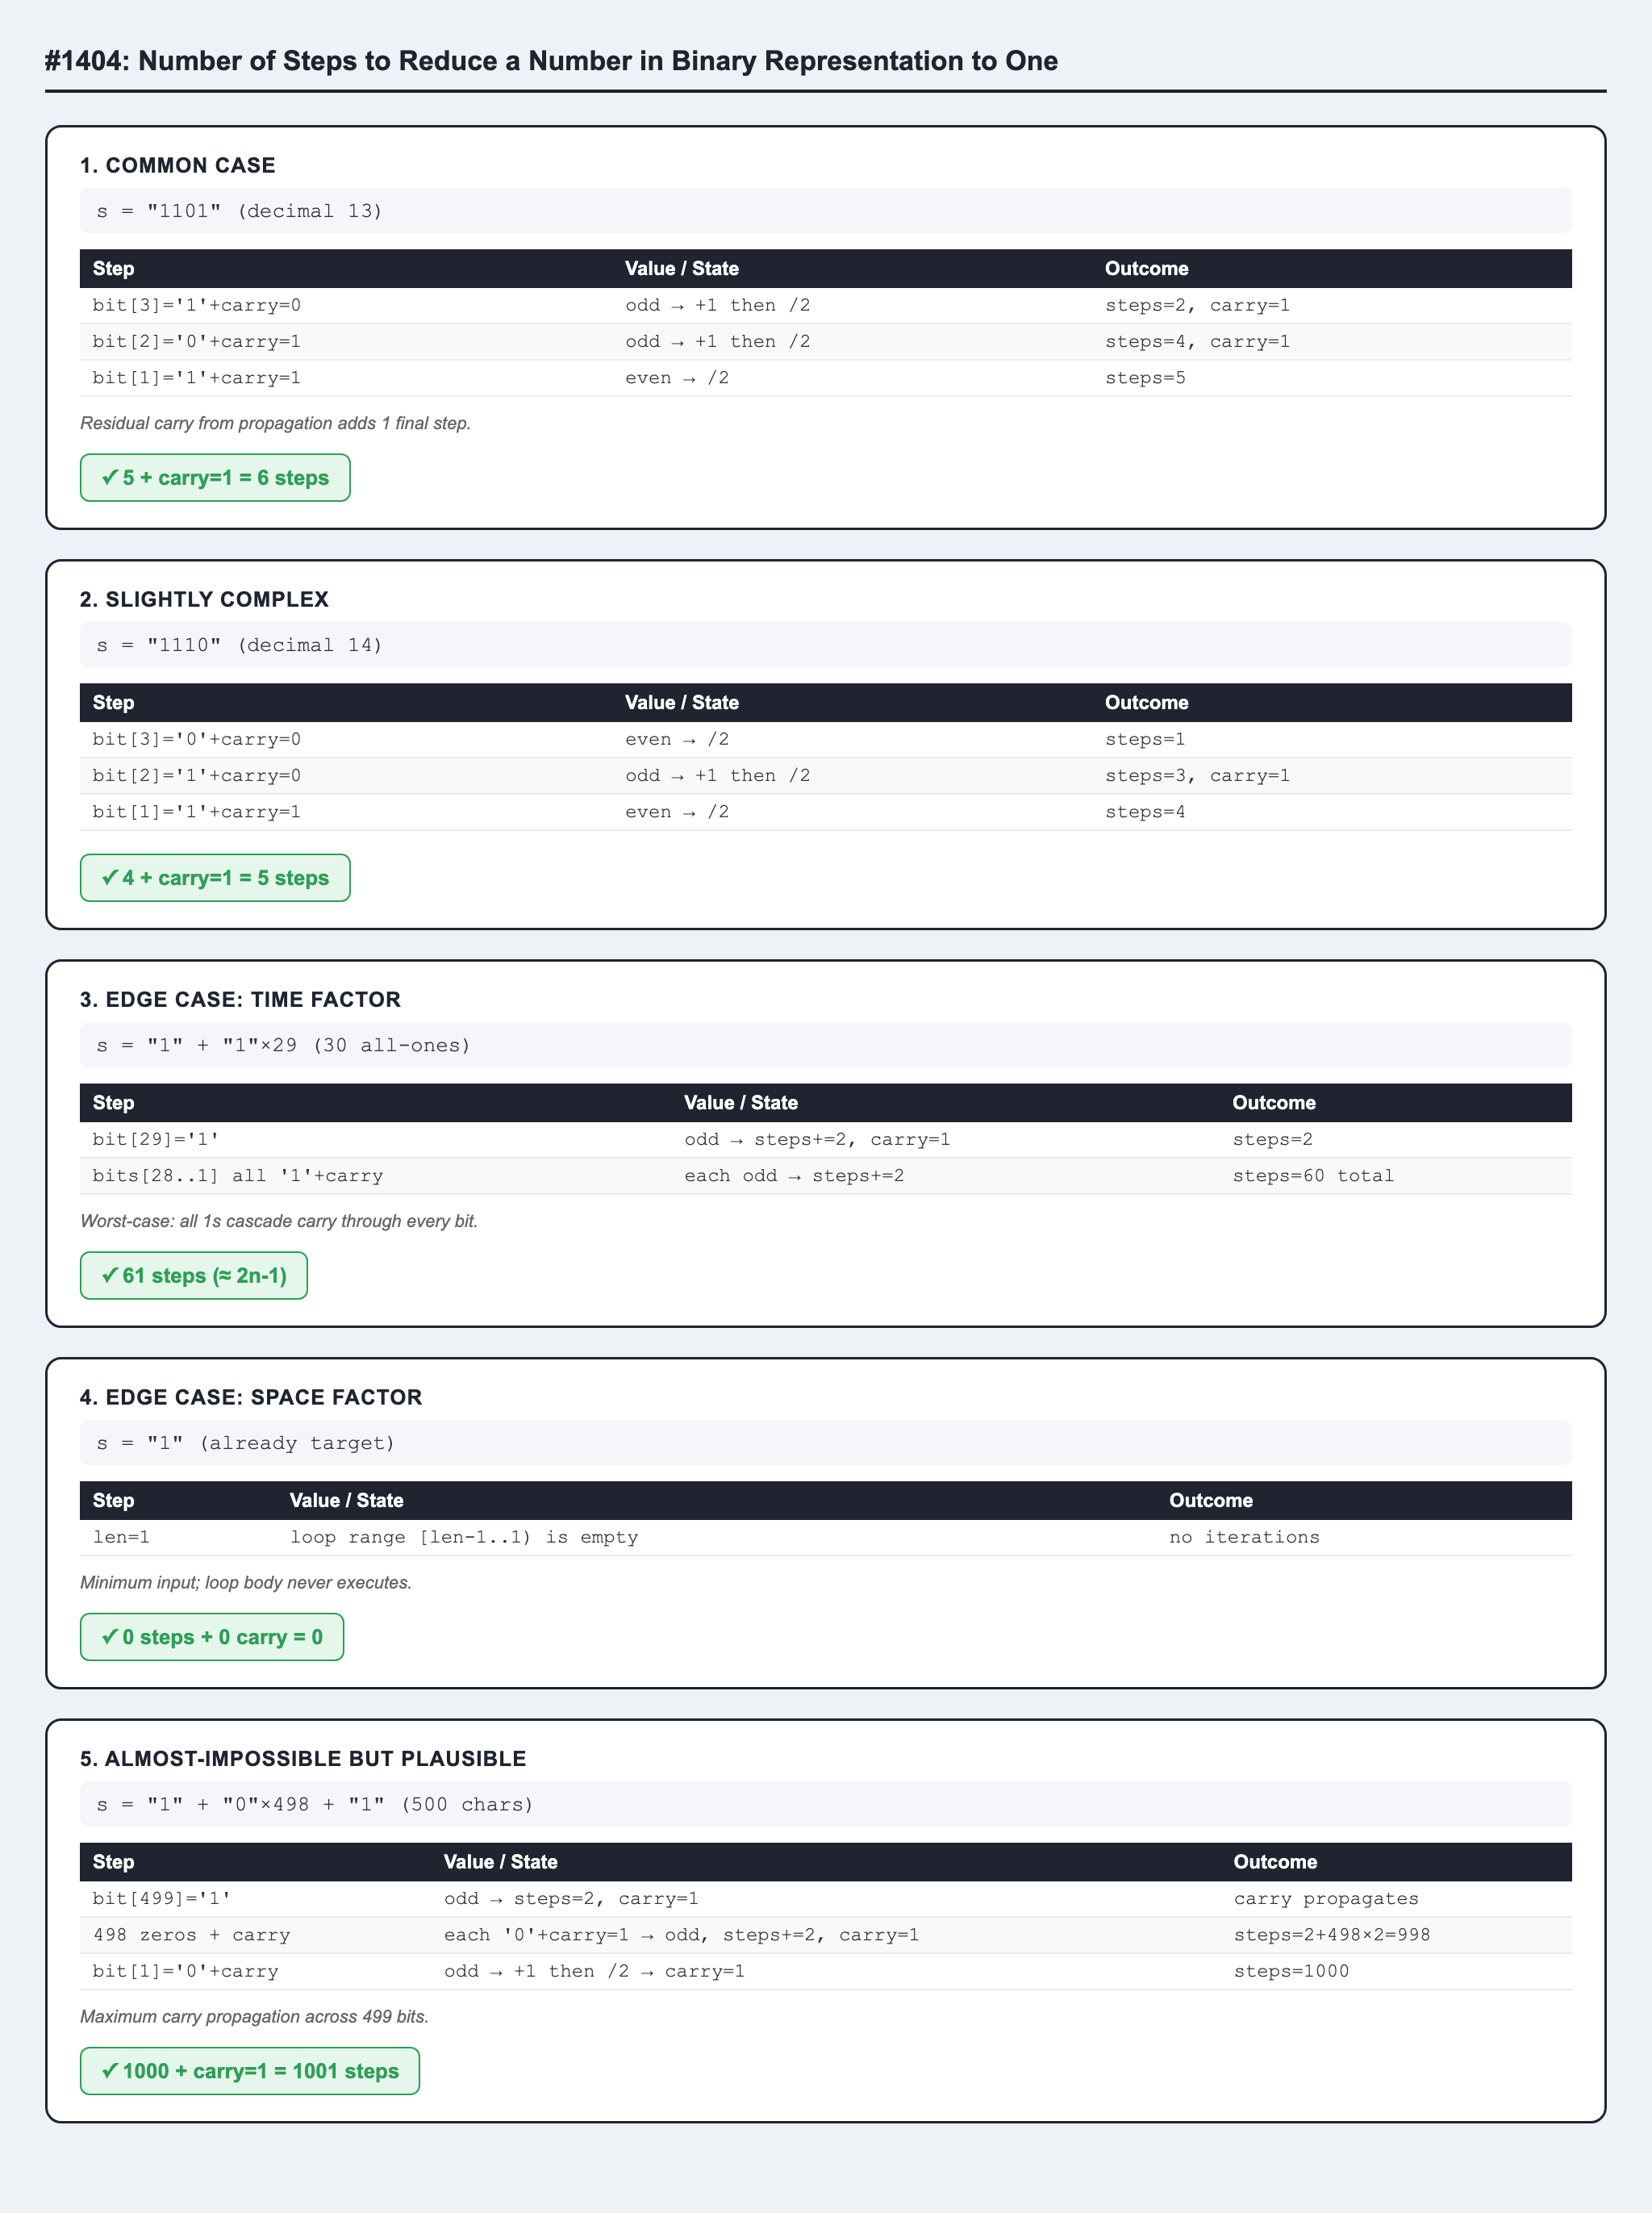